# 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

릿지회귀

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_openml
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

# boston 데이터 로드 (사이킷런에서 load_boston()이 삭제되어 fetch_openml 사)
boston = fetch_openml(name="boston", version=1)

# boaston 데이터 세트 DataFrame 변환
bostonDF = boston.frame
bostonDF = bostonDF.apply(pd.to_numeric, errors='coerce')

# boston 데이터 세트의 target 배열은 주택 가격, 이를 PRICE 칼럼으로 DataFrame에 추가
bostonDF['PRICE'] = boston.target
print('Boston 데이터 세트 크기:', bostonDF.shape)
bostonDF.head()

Boston 데이터 세트 크기: (506, 15)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2


In [17]:
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha=10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print(' 5 folds의 평균 RMSE: {0:3f}'.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [-0. -0. -0. -0. -0.]
 5 folds의 개별 RMSE scores:  [0.003 0.005 0.006 0.014 0.006]
 5 folds의 평균 RMSE: 0.006783


In [20]:
# 릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

# alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE: 0.000
alpha 0.1일 때 5 folds의 평균 RMSE: 0.000
alpha 1일 때 5 folds의 평균 RMSE: 0.001
alpha 10일 때 5 folds의 평균 RMSE: 0.007
alpha 100일 때 5 folds의 평균 RMSE: 0.054


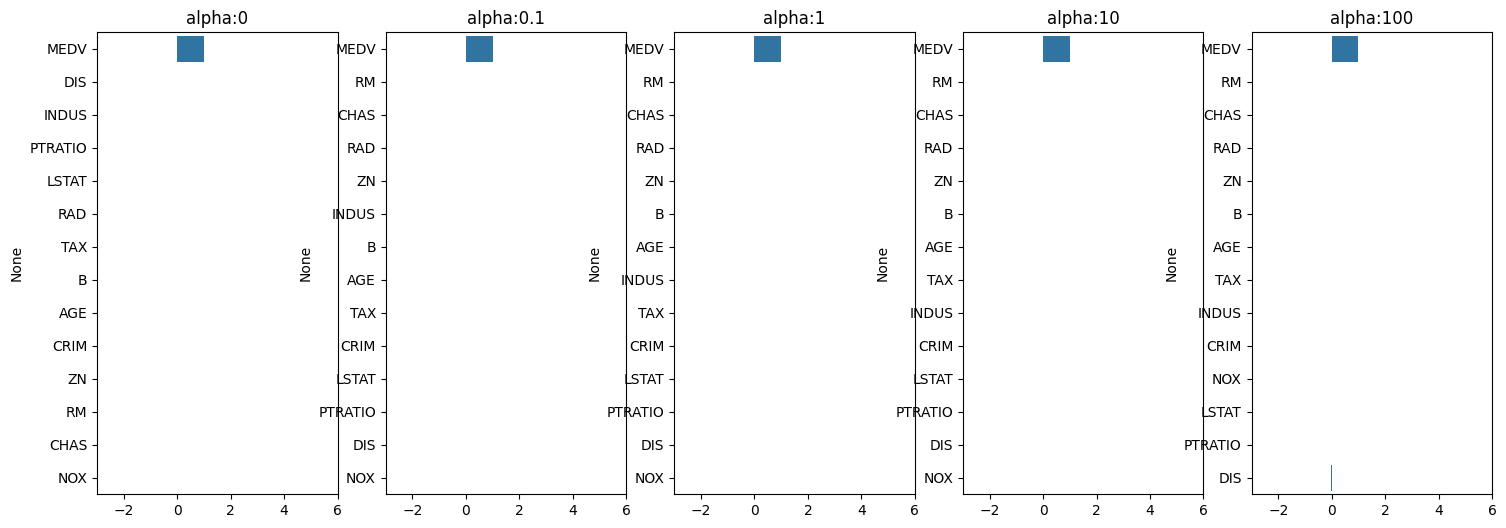

In [22]:
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig , axs = plt.subplots(figsize=(18,6) , nrows=1 , ncols=5)
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장, pos는 axis의 위치 지정
for pos , alpha in enumerate(alphas) :
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data , y_target)
    # alpha에 따른 피처별로 회귀 계수를 Series 로 변환하고 이를 DataFrame의 칼럼으로 추가
    coeff = pd.Series(data=ridge.coef_ , index=X_data.columns )
    colname='alpha:'+str(alpha)
    coeff_df[colname] = coeff
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화, 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values , y=coeff.index, ax=axs[pos])

# for 문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표
plt.show()

In [23]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending = False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
MEDV,1.000000e+00,9.999910e-01,9.999115e-01,0.999148,0.992309
DIS,4.447561e-15,-1.313671e-05,-1.215164e-04,-0.001064,-0.008871
INDUS,1.484007e-15,1.439919e-07,-7.794484e-07,-0.000037,-0.000406
PTRATIO,1.205267e-15,-8.466879e-06,-7.755589e-05,-0.000680,-0.006378
LSTAT,3.037564e-16,-4.733725e-06,-4.721507e-05,-0.000477,-0.005082
RAD,2.554083e-16,2.731654e-06,2.568525e-05,0.000238,0.002426
TAX,-1.456319e-17,-1.117860e-07,-1.143024e-06,-0.000012,-0.000122
B,-2.383934e-17,8.431319e-08,8.563426e-07,0.000009,0.000072
AGE,-6.930257e-17,-2.421560e-09,-4.793307e-07,-0.000009,0.000009
CRIM,-7.198836e-17,-9.672694e-07,-9.259465e-06,-0.000086,-0.000786


라쏘 회귀

In [24]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DF로 반환
def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):
    coeff_df = pd.DataFrame()
    if verbose : print('####### ', model_name , '#######')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name == 'Lasso': model = Lasso(alpha=param)
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio = 0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = "neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 컬럼으로 추가
            coeff = pd.Series(data = model.coef_ , index = X_data_n.columns )
            colname='alpha:'+str(param)
            coeff_df[colname] = coeff

    return coeff_df
  # end of get_linear_regre_eval

In [25]:
# 라쏘에 사용할 alpha 파라미터 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [ 0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df =get_linear_reg_eval('Lasso', params = lasso_alphas, X_data_n = X_data, y_target_n = y_target)

#######  Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 0.009
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.013
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 0.066
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.132
alpha 3일 때 5 폴드 세트의 평균 RMSE: 0.394


In [26]:
# 반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MEDV,0.998953,0.998504,0.992499,0.984999,0.954994
B,0.000009,0.000013,0.000064,0.000126,0.000370
INDUS,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
CHAS,0.000000,0.000000,0.000000,0.000000,0.000000
CRIM,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
ZN,0.000000,0.000000,0.000000,0.000000,0.000000
RM,0.000000,0.000000,0.000000,0.000000,0.000000
NOX,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
AGE,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
DIS,0.000000,0.000000,0.000000,0.000000,0.000000


엘라스틱넷 회

In [27]:
# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ratio는 0.7로 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params = elastic_alphas,
                                       X_data_n = X_data, y_target_n = y_target)

#######  ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 0.009
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.013
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 0.066
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.132
alpha 3일 때 5 폴드 세트의 평균 RMSE: 0.393


In [28]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DF 출
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MEDV,0.998937,0.998478,0.992432,0.984892,0.955128
B,0.000012,0.000017,0.000081,0.000161,0.000473
ZN,0.000002,0.000006,0.000005,0.000004,0.000000
CHAS,0.000000,0.000000,0.000000,0.000000,0.000000
INDUS,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
CRIM,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
RM,0.000000,0.000000,0.000000,0.000000,0.000000
NOX,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
AGE,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
DIS,0.000000,0.000000,0.000000,0.000000,0.000000


선형 회귀 모델을 위한 데이터 변환

In [30]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최대값/최소값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다향식 특성을 추가할 때 적용, p_degree는 2이상 부여하지 않음
def get_scaled_data(method = 'None', p_degree = None, input_data = None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree = p_degree, include_bias = False).fit_transform(scaled_data)

    return scaled_data

In [31]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규분포, 표준정규분포+다항식 특성
# 최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환
scale_methods = [(None, None), ('Standard', None), ('Standard', 2),
                 ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method = scale_method[0], p_degree = scale_method[1],
                                    input_data = X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params = alphas, X_data_n = X_data_scaled,
                        y_target_n = y_target, verbose = False, return_coeff = False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.000
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.001
alpha 10일 때 5 폴드 세트의 평균 RMSE: 0.007
alpha 100일 때 5 폴드 세트의 평균 RMSE: 0.054

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.007
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.065
alpha 10일 때 5 폴드 세트의 평균 RMSE: 0.541
alpha 100일 때 5 폴드 세트의 평균 RMSE: 2.343

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.095
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.512
alpha 10일 때 5 폴드 세트의 평균 RMSE: 1.582
alpha 100일 때 5 폴드 세트의 평균 RMSE: 3.031

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.150
alpha 1일 때 5 폴드 세트의 평균 RMSE: 1.004
alpha 10일 때 5 폴드 세트의 평균 RMSE: 3.308
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.803

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 0.500
alpha 1일 때 5 폴드 세트의 평균 RMSE: 0.709
alpha 10일 때 5 폴드 세트의 평균 RMSE: 1.665
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.540

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 2.553

# 로지스틱 회귀

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler( )로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size = 0.3,
                                                    random_state = 0)

In [34]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행
# solver 인자값을 생성자로 입력하지 않으면 solver='lbfgs'
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

print('accuracy: {0:.3f}, roc_auc:{1:.3f}'.format(accuracy_score(y_test, lr_preds),
                                                  roc_auc_score(y_test, lr_preds_proba)))

accuracy: 0.977, roc_auc:0.995


In [35]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

# 여러 개의 solver 값별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver = solver, max_iter = 600) #최대 반복 횟수 600
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)
    lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

    print('solver:{0}, accuracy: {1:.3f}, roc_auc:{2:.3f}'.format(solver,
                                                                  accuracy_score(y_test, lr_preds),
                                                                  roc_auc_score(y_test, lr_preds_proba)))

solver:lbfgs, accuracy: 0.977, roc_auc:0.995
solver:liblinear, accuracy: 0.982, roc_auc:0.995
solver:newton-cg, accuracy: 0.977, roc_auc:0.995
solver:sag, accuracy: 0.982, roc_auc:0.995
solver:saga, accuracy: 0.982, roc_auc:0.995


In [36]:
from sklearn.model_selection import GridSearchCV

params={'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l2', 'l1'],
        'C': [0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = 'accuracy', cv = 3 )
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_,
                                                  grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979
